<a href="https://colab.research.google.com/github/oliviergentil/MAR_Explorer/blob/main/Copie_de_Untitled6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [629]:
!python -m pip install \
    --index-url https://test.pypi.org/simple/ \
    --extra-index-url https://pypi.org/simple/ \
    mar-explorer

Looking in indexes: https://test.pypi.org/simple/, https://pypi.org/simple/


In [630]:
import requests
import matplotlib.pyplot as plt
import pandas as pd
import mar_explorer as mar


url = "https://raw.githubusercontent.com/oliviergentil/MAR_Explorer/main/mar.json"

response = requests.get(url)
response.raise_for_status()

data = response.json()

In [631]:
mar = mar.MAR(data)

In [632]:
mar.list_tables(years=[2025, 2024, 2023], keyword="exhaustion")


=== 2025 ===

  Chapter 2:
    26. Table 26: Entitlement and benefit period exhaustion rates of completed claims for Employment Insurance regular benefits by province or territory, gender, age and claimant category, Canada, 2023-24 and 2024-25
    27. Table 27: Completed claims for Employment Insurance regular benefits by exhaustion type and characteristics, Canada, 2024-25

=== 2024 ===

  Chapter 2:
    25. Table 25 – Entitlement and benefit period exhaustion rates of completed claims for Employment Insurance regular benefits by province or territory, gender, age and claimant category, Canada, 2022‑23 to 2023‑24*
    26. Table 26 – Completed claims for Employment Insurance regular benefits by exhaustion type and characteristics, Canada, 2023‑24*

=== 2023 ===

  Chapter 2:
    30. Table 30 – Entitlement and benefit period exhaustion rates of completed claims for Employment Insurance regular benefits established between September 27, 2020 and September 25, 2021 by province or territo

In [633]:
exhaustion_2023 = mar.table(2023, 2, 30)
exhaustion_2024 = mar.table(2024, 2, 25)
exhaustion_2025 = mar.table(2025, 2, 26)

exhaustion = exhaustion_2023.data.merge(
    exhaustion_2024.data,
    on="Category"
).merge(
    exhaustion_2025.data,
    on="Category"
)

In [634]:
for x, y in enumerate(exhaustion.columns):
    print(x, y)

0 Category
1 Entitlement exhaustion rateP
2 Benefit period exhaustion rateP
3 Entitlement exhaustion rate 2022‑23
4 Entitlement exhaustion rate 2023‑24P
5 Change in entitlement exhaustion rate (% points)
6 Benefit period exhaustion rate 2022‑23
7 Benefit period exhaustion rate 2023‑24P
8 Change in benefit period exhaustion rate (% points)
9 Entitlement exhaustion rate 2023-24R
10 Entitlement exhaustion rate 2024-25P
11 Change (% points) in entitlement exhaustion rate
12 Benefit period exhaustion rate 2023-24R
13 Benefit period exhaustion rate 2024-25P
14 Change (% points) in benefit period exhaustion rate


In [635]:
exhaustion = exhaustion.rename(columns={
    exhaustion.columns[1]: 'Entitlement exhaustion rateP sept-2020/sept-2021',
    exhaustion.columns[2]: 'Benefit period exhaustion rateP sept-2020-sept-2021'
})

In [636]:
for x,y in enumerate(exhaustion.columns):
  print(x,y)

0 Category
1 Entitlement exhaustion rateP sept-2020/sept-2021
2 Benefit period exhaustion rateP sept-2020-sept-2021
3 Entitlement exhaustion rate 2022‑23
4 Entitlement exhaustion rate 2023‑24P
5 Change in entitlement exhaustion rate (% points)
6 Benefit period exhaustion rate 2022‑23
7 Benefit period exhaustion rate 2023‑24P
8 Change in benefit period exhaustion rate (% points)
9 Entitlement exhaustion rate 2023-24R
10 Entitlement exhaustion rate 2024-25P
11 Change (% points) in entitlement exhaustion rate
12 Benefit period exhaustion rate 2023-24R
13 Benefit period exhaustion rate 2024-25P
14 Change (% points) in benefit period exhaustion rate


In [637]:
exhaustion = exhaustion.iloc[:, [0,1,3,9,10,2,6,12,13]]

In [638]:
exhaustion

,Category,Entitlement exhaustion rateP sept-2020/sept-2021,Entitlement exhaustion rate 2022‑23,Entitlement exhaustion rate 2023-24R,Entitlement exhaustion rate 2024-25P,Benefit period exhaustion rateP sept-2020-sept-2021,Benefit period exhaustion rate 2022‑23,Benefit period exhaustion rate 2023-24R,Benefit period exhaustion rate 2024-25P
0,Newfoundland and Labrador,45.9%,34.5%R,40.9%,39.6%,39.3%,39.4%R,36.7%,36.6%
1,Prince Edward Island,32.6%,40.8%R,43.4%,37.3%,30.7%,25.6%,27.2%,30.4%
2,Nova Scotia,47.7%,43.4%R,44.5%,39.5%,33.3%,21.8%R,23.0%,25.0%
3,New Brunswick,32.6%,37.3%,42.0%,36.3%,33.7%,32.5%R,30.8%,34.6%
4,Quebec,34.9%,34.1%R,30.4%,29.4%,44.3%,18.4%R,24.5%,23.9%
5,Ontario,42.7%,35.7%R,34.5%,35.9%,36.6%,11.7%R,16.5%,15.0%
6,Manitoba,45.0%,38.9%,35.7%,35.2%,35.7%,12.9%R,19.6%,19.8%
7,Saskatchewan,49.5%,36.5%R,37.1%,35.7%,28.9%,15.4%R,19.5%,19.5%
8,Alberta,44.0%,38.6%R,36.3%,35.3%,36.1%,11.2%R,16.4%,16.1%
9,British Columbia,34.0%,38.6%R,36.8%,36.3%,45.4%,10.8%R,14.6%,16.4%


In [639]:
exhaustion = exhaustion.replace("R", "", regex=True)

In [640]:
for col in exhaustion.columns[1:]:
    exhaustion[col] = (
        exhaustion[col]
        .str.replace("%", "", regex=False)
        .astype(float)
    )

In [641]:
exhaustion_2 = exhaustion.iloc[13:, ]

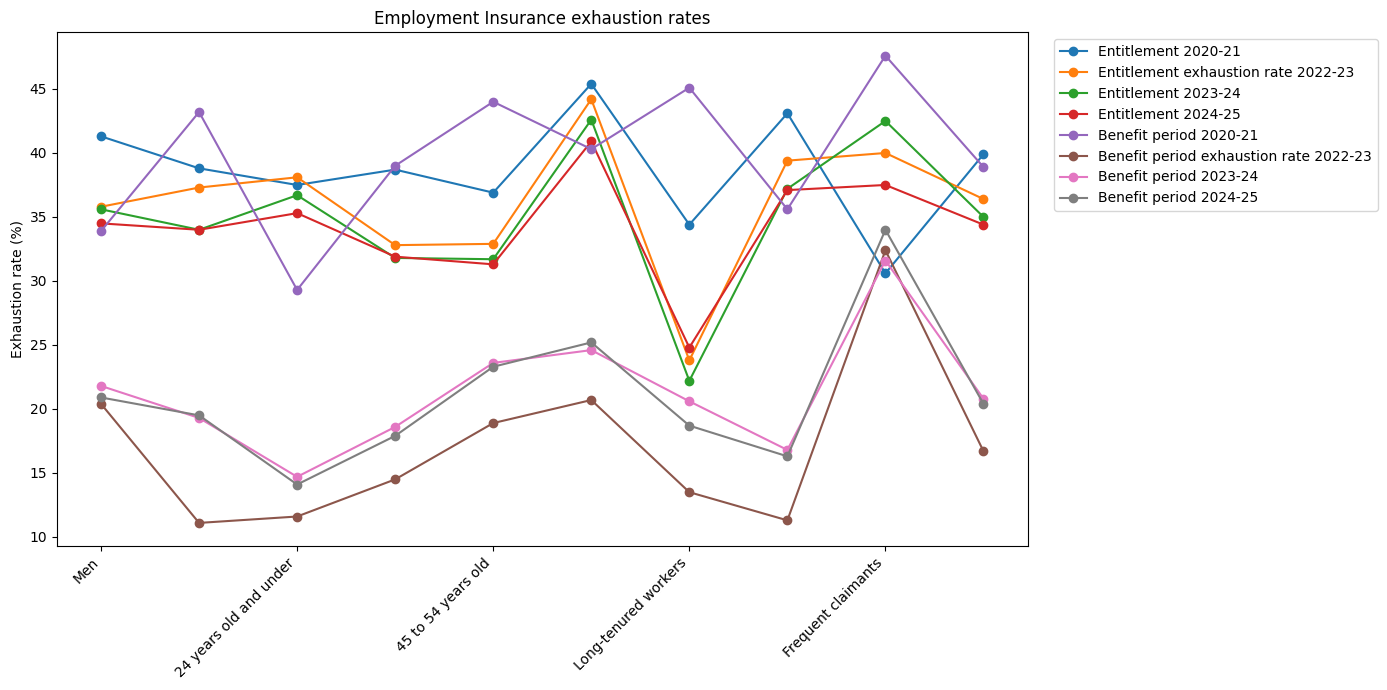

In [642]:
exhaustion_2 = exhaustion_2.rename(columns={
    "Entitlement exhaustion rateP sept-2020/sept-2021": "Entitlement 2020-21",
    "Entitlement exhaustion rate 2022-23": "Entitlement 2022-23",
    "Entitlement exhaustion rate 2023-24R": "Entitlement 2023-24",
    "Entitlement exhaustion rate 2024-25P": "Entitlement 2024-25",
    "Benefit period exhaustion rateP sept-2020-sept-2021": "Benefit period 2020-21",
    "Benefit period exhaustion rate 2022-23": "Benefit period 2022-23",
    "Benefit period exhaustion rate 2023-24R": "Benefit period 2023-24",
    "Benefit period exhaustion rate 2024-25P": "Benefit period 2024-25"
})

ax = exhaustion_2.plot(
    x="Category",
    figsize=(14, 7),
    marker="o"
)

ax.set_ylabel("Exhaustion rate (%)")
ax.set_xlabel("")
ax.set_title("Employment Insurance exhaustion rates")
ax.legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

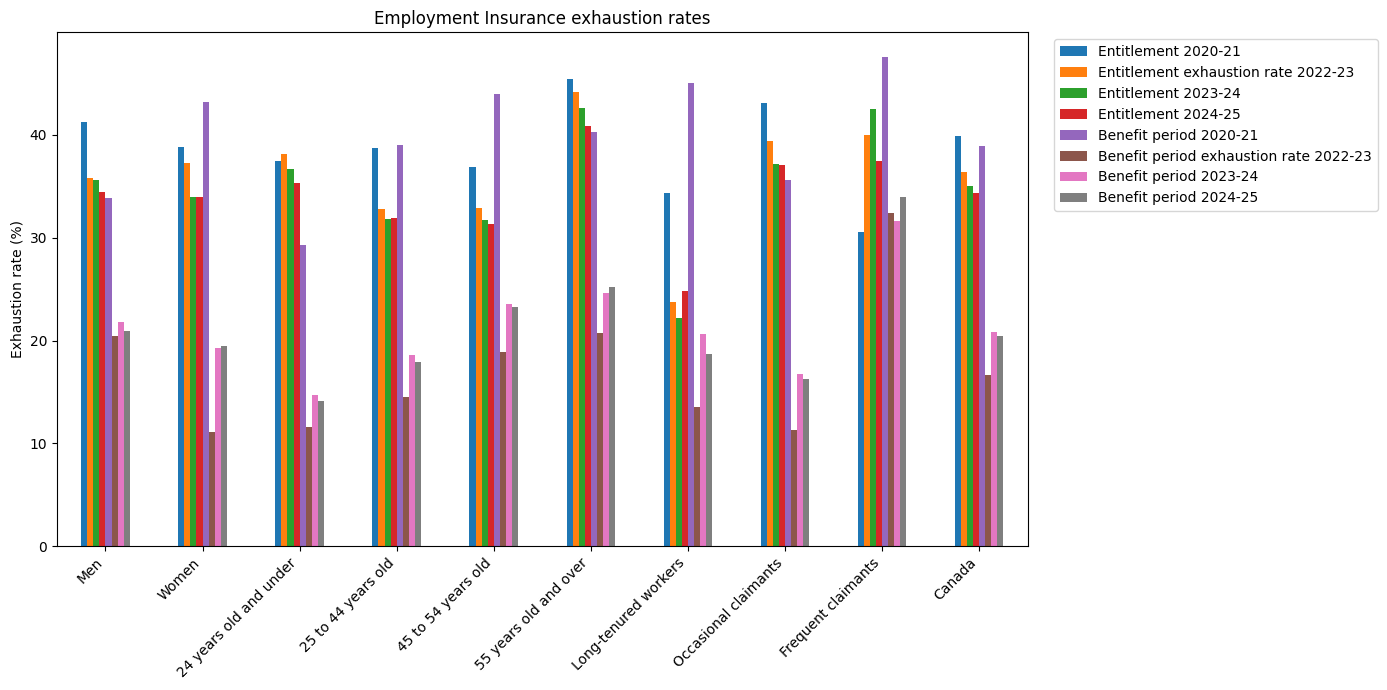

In [643]:
exhaustion_2.plot(
    x="Category",
    kind="bar",
    figsize=(14, 7)
)
plt.ylabel("Exhaustion rate (%)")
plt.xlabel("")
plt.title("Employment Insurance exhaustion rates")
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

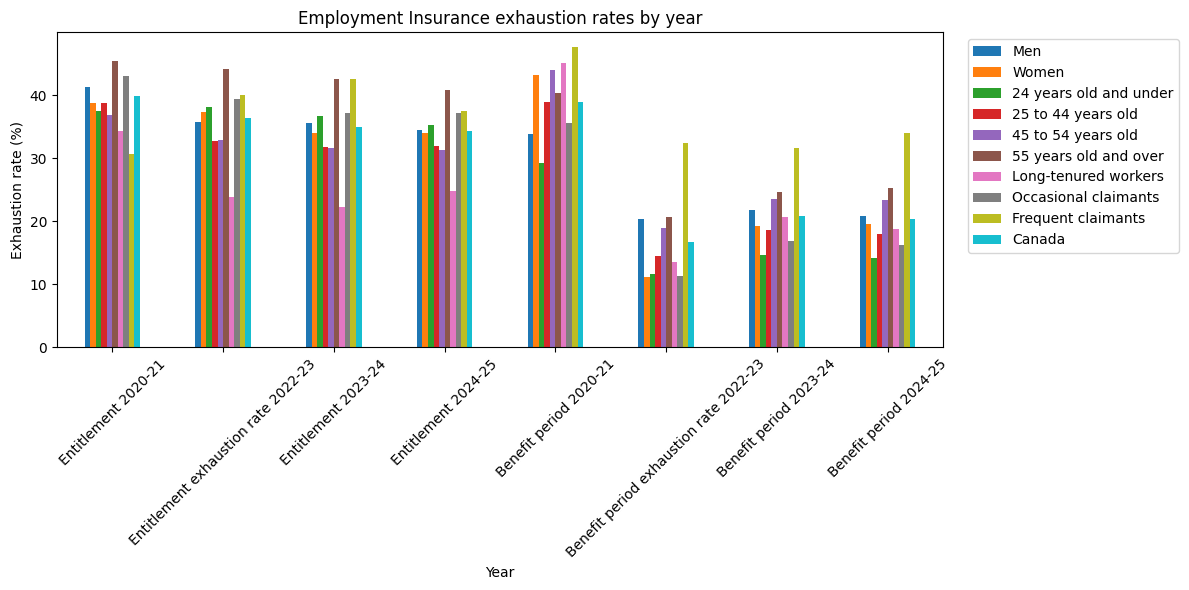

In [644]:
exhaustion_2.set_index("Category").T.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("Exhaustion rate (%)")
plt.xlabel("Year")
plt.title("Employment Insurance exhaustion rates by year")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

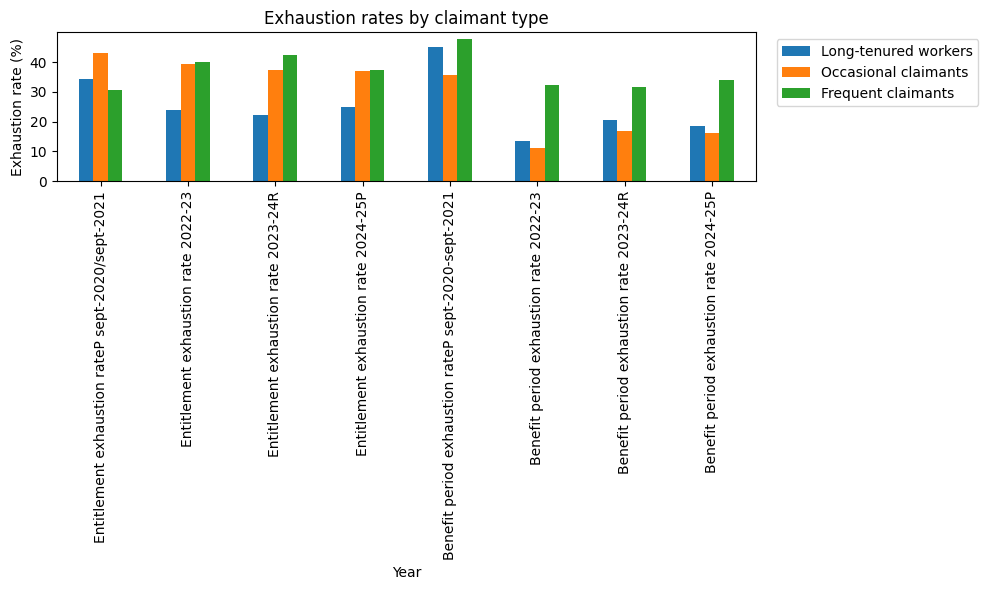

In [645]:
claimants = exhaustion.iloc[19:22]

claimants.set_index("Category").T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Exhaustion rate (%)")
plt.xlabel("Year")
plt.title("Exhaustion rates by claimant type")
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [646]:
mar.list_tables(keyword="Proportion of Employment Insurance regular benefits' weeks used")


=== 2015 ===

=== 2017 ===

=== 2018 ===

=== 2019 ===

=== 2020 ===

=== 2021 ===

=== 2022 ===

=== 2023 ===

=== 2024 ===

  Chapter 2:
    23. Table 23 – Proportion of Employment Insurance regular benefits' weeks used, by province or territory, gender, age and claimant category, Canada, 2022‑23 to 2023‑24*
    24. Table 24 – Proportion of Employment Insurance regular benefits' weeks used by weeks of entitlement, EI regional unemployment rate and working while on claim status, Canada, 2022‑23 to 2023‑24*

=== 2025 ===

  Chapter 2:
    24. Table 24: Proportion of Employment Insurance regular benefits' weeks used, by province or territory, gender, age and claimant category, Canada, 2023-24 and 2024-25


In [647]:
exhaustion_3 = mar.table(2024, 2, 23).data.iloc[:, :3].merge(
    mar.table(2025, 2, 24).data.iloc[:, :3],
    on="Category"
)

In [648]:
for x,y in enumerate(exhaustion_3.columns):
  print(x,y)

0 Category
1 2022‑23R
2 2023‑24P
3 2023-24R
4 2024-25P


In [649]:
exhaustion_3 = exhaustion_3.iloc[15:, [0, 1, 3, 4]]
exhaustion_3

,Category,2022‑23R,2023-24R,2024-25P
15,24 years old and under,60.8%,60.7%,59.5%
16,25 to 44 years old,60.1%,59.2%,59.1%
17,45 to 54 years old,62.5%,60.8%,60.4%
18,55 years old and over,72.9%,71.3%,70.2%
19,Long-tenured workers,48.6%,47.6%,49.6%
20,Occasional claimants,64.6%,63.3%,62.9%
21,Frequent claimants,76.2%,77.2%,74.7%
22,Canada,64.1%,62.7%,62.2%


In [650]:
exhaustion_3.iloc[:, 1:] = (
    exhaustion_3.iloc[:, 1:]
    .replace("%", "", regex=True)
    .astype(float)
)

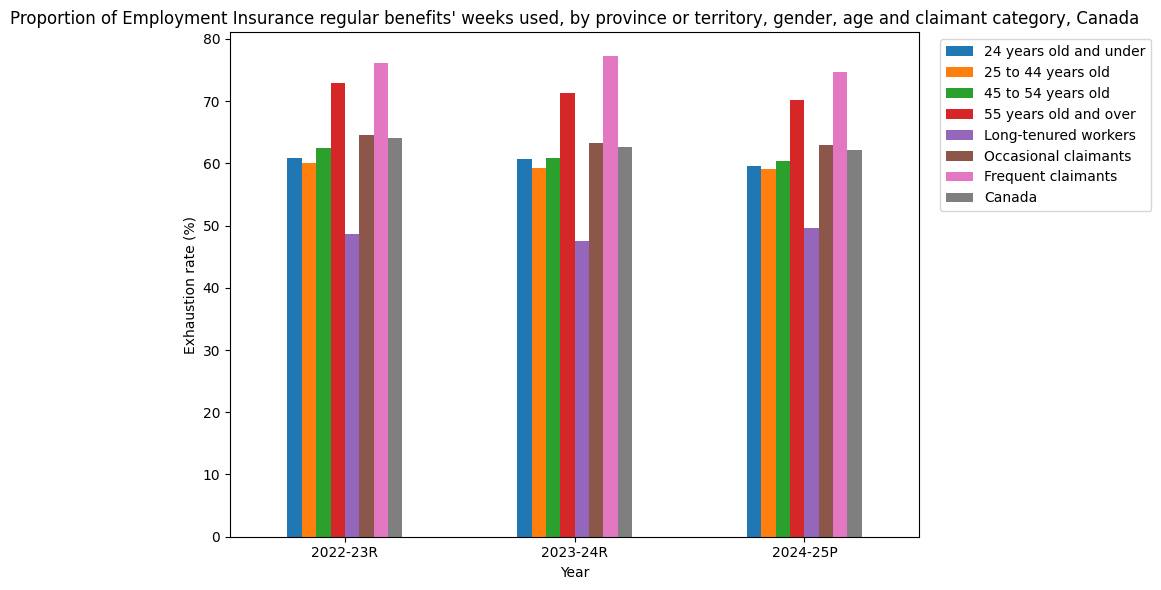

In [651]:
exhaustion_3.set_index("Category").T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Exhaustion rate (%)")
plt.xlabel("Year")
plt.title("Proportion of Employment Insurance regular benefits' weeks used, by province or territory, gender, age and claimant category, Canada")
plt.xticks(rotation=0)

plt.legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()